# Dataset description
## unemployment in people aged 18-24 with a tertiary degree
**Source**: OECD

**Download**: [link](https://data-explorer.oecd.org/vis?fs[0]=Topic,1%7CEducation%20and%20skills%23EDU%23%7CYouth%20and%20the%20labour%20market%23EDU_YOU%23&pg=0&fc=Topic&bp=true&snb=24&vw=tb&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_EAG_LSO_EA%40DF_LSO_TRANS&df[ag]=OECD.EDU.IMEP&df[vs]=1.0&dq=COL.M%2BF.Y18T24.ISCED11A_5T8......ED%2BNED.EMP%2BUNE...OBS...A&pd=1997,2025&to[TIME_PERIOD]=true)

# Code
## Imports

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [12]:
path = "./data/education.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [14]:
df_f = df[
    (df["Education status"].eq("Not in education")) &
    (df["Labour force status"].eq("Unemployment"))
][["Sex", "TIME_PERIOD", "OBS_VALUE"]]

male = df_f[df_f["Sex"].eq("Male")].set_index("TIME_PERIOD")["OBS_VALUE"]
female = df_f[df_f["Sex"].eq("Female")].set_index("TIME_PERIOD")["OBS_VALUE"]

TIME_PERIOD
2007   16.73
2008   20.76
2009   19.77
2010   18.71
2011   18.54
2012   16.67
2013   15.82
2014   15.50
2015   15.67
2016   16.63
2017   16.70
2018   17.38
2019   19.30
2020   23.00
2021   21.55
2022   17.88
2023   15.89
2024   18.00
2025   17.49
Name: OBS_VALUE, dtype: float64

## Plot

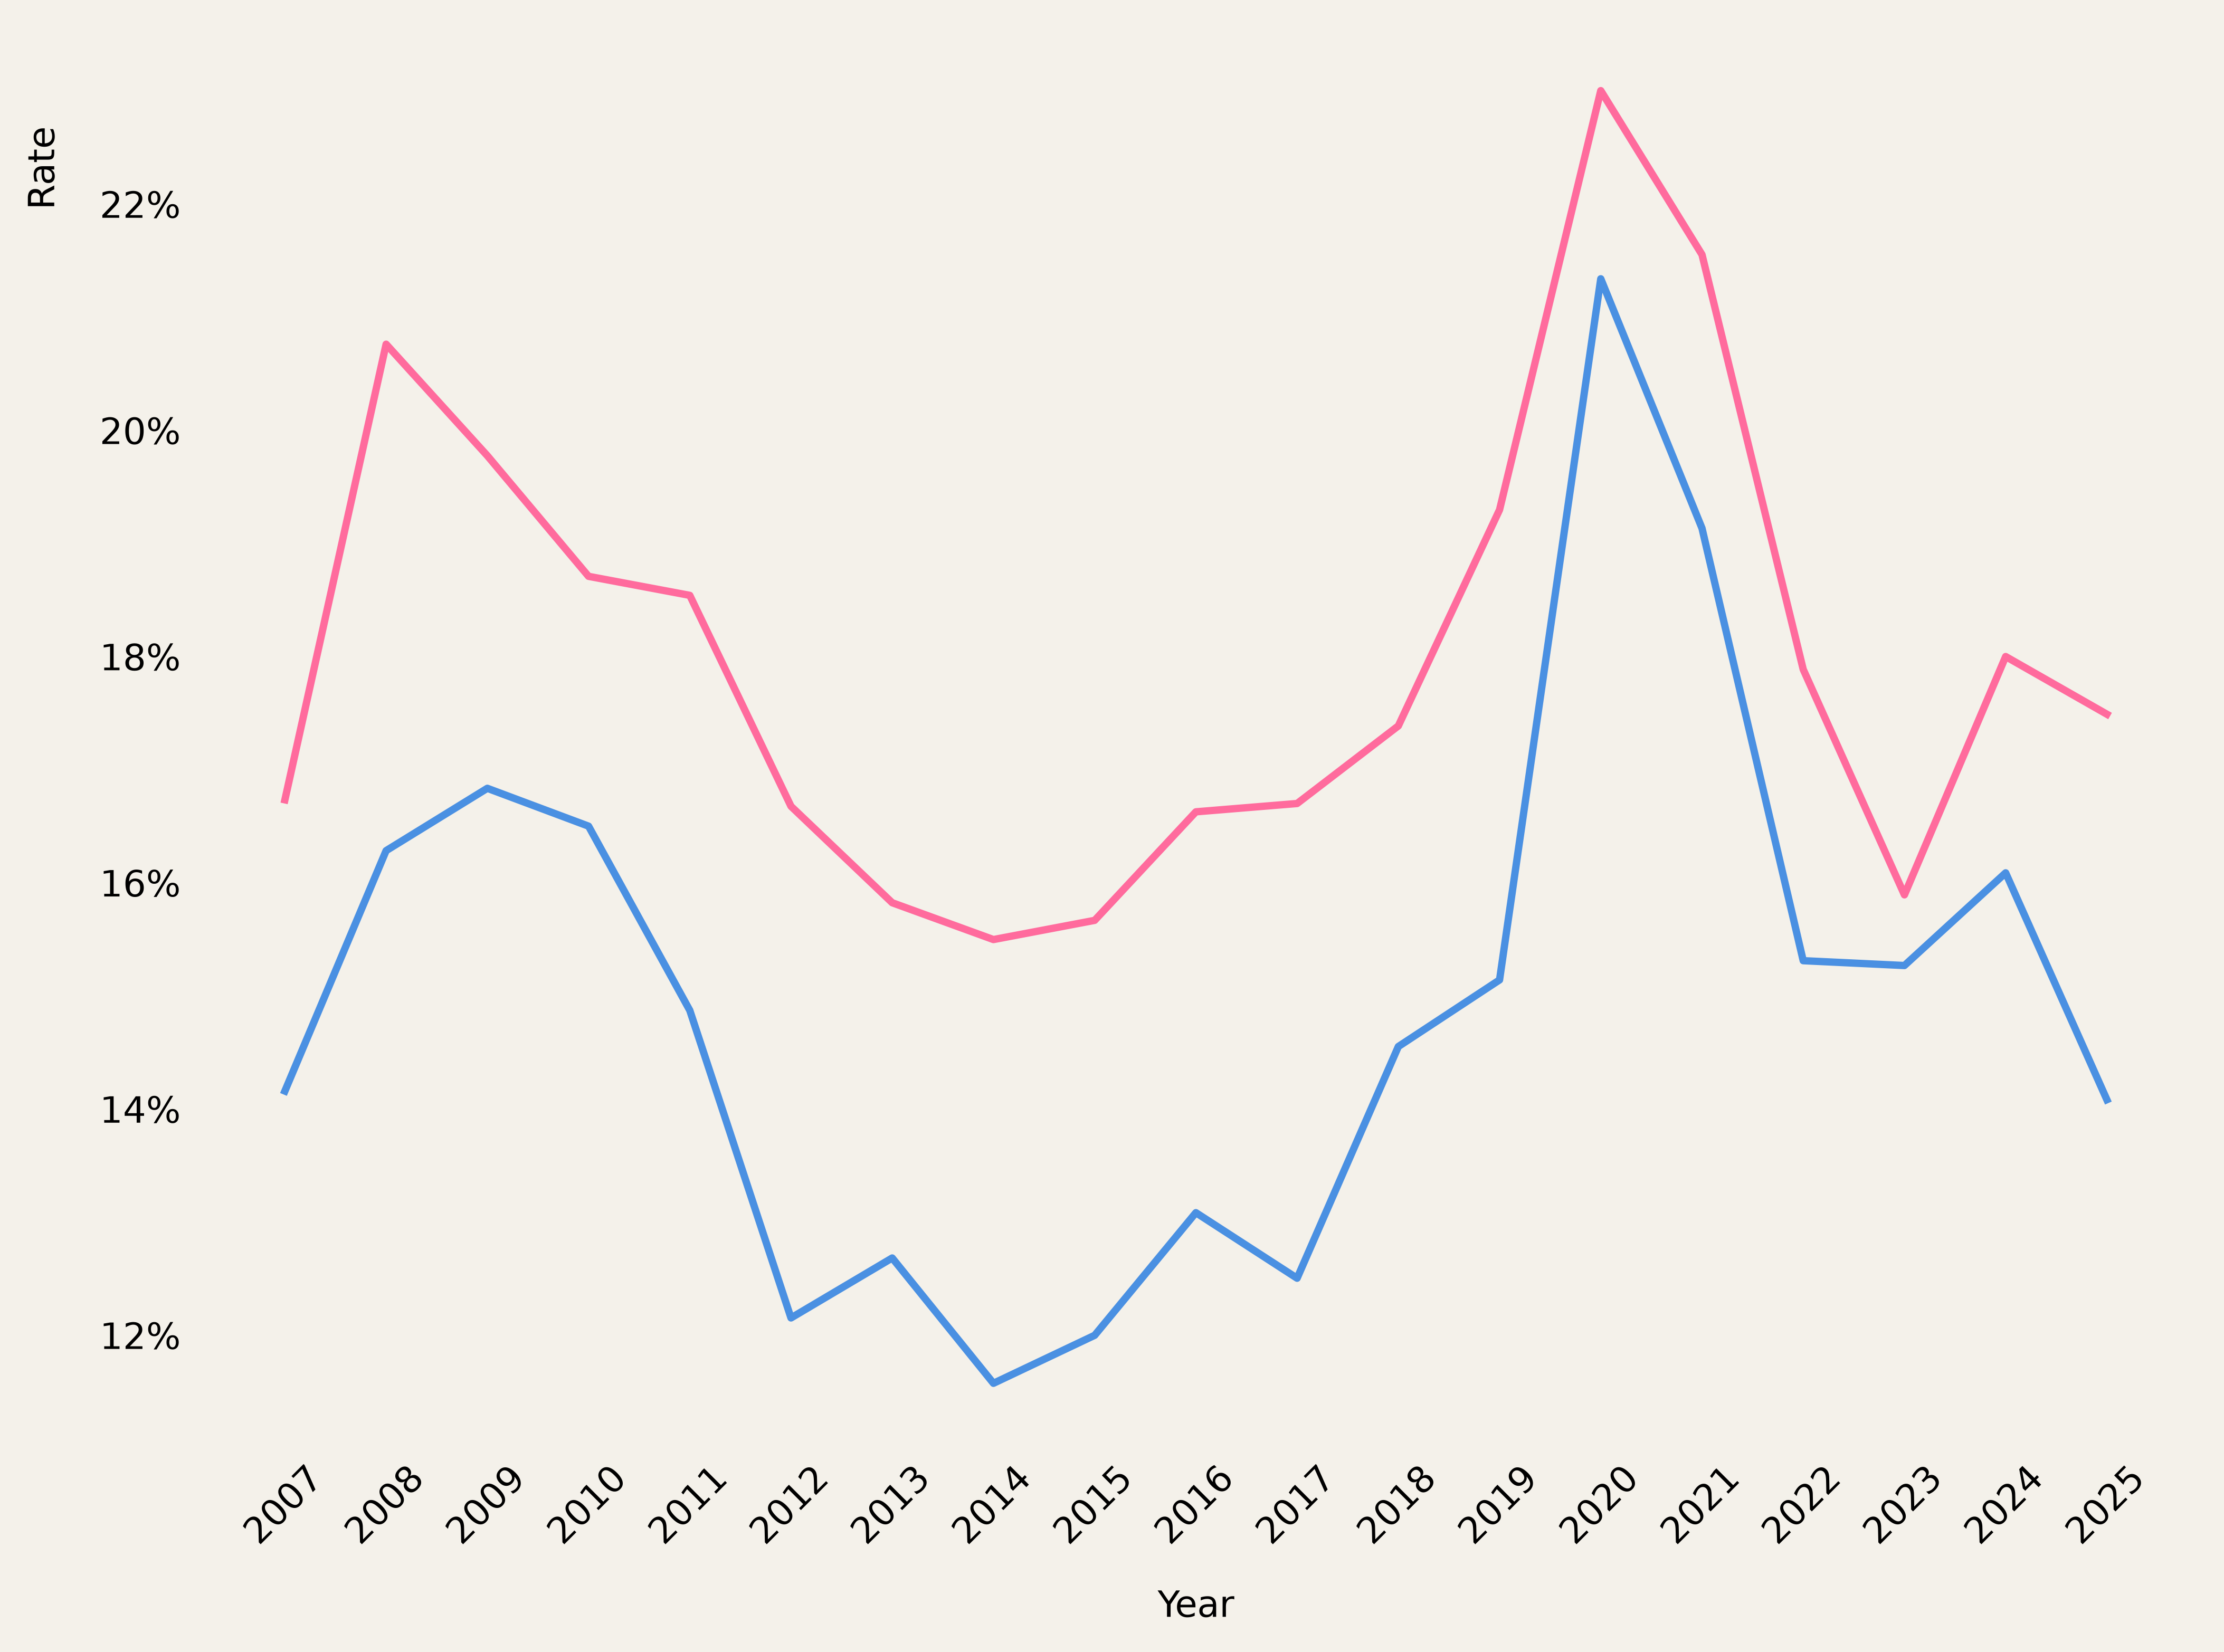

In [18]:
background = "#F4F1EA"
female_color = "#FF6B9D"
male_color = "#4a90e2"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(male, linewidth=2, color=male_color)
plt.plot(female, linewidth=2, color=female_color)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Rate", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.xticks(male.index, rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.show()